# Graph Node Features: Predicting a Missing User Label

This notebook builds a small relational e-commerce database with three tables:

- `users`
- `items`
- `purchases`

We convert the tables into a graph with `networkx`, compute graph-based node features for users, and use one of those features for a simple node-classification task.

**Learning task:** predict whether a user is a parent (`is_parent`) when this label is missing for some users.

**Main idea:** raw user columns such as age or country are weak. The user's neighborhood in the purchase graph is much more informative: users who often buy baby/toy/kids items are likely to be parents.

## Example Design and Learning Task

This example is a small **heterogeneous graph learning** problem built from an e-commerce relational database.

**Relational data.** The database has three tables:

- `users`: one row per user, with raw attributes such as `age`, `country`, and `signup_channel`.
- `items`: one row per item, with attributes such as `category`, `price`, and `family_signal`.
- `purchases`: one row per purchase event, with foreign keys `user_id` and `item_id`.

**Labels.** The target label is `is_parent` on `User` nodes. A value of `1` means the user is a parent, and `0` means the user is not a parent. In the example, labels for users 7 and 8 are hidden to simulate missing labels.

**Learning task.** This is a **node classification** task: given the graph structure and observed labels for some users, predict the missing `is_parent` label for unlabeled user nodes.

**Graph construction.** We use tuple-level conversion from the relational database to a graph:

- Every `users` row becomes a `User` node.
- Every `items` row becomes an `Item` node.
- Every `purchases` row becomes a `Purchase` node.
- Foreign keys become edges: `User -- Purchase -- Item`.

**Computed graph features.** For each user, we aggregate information from its purchased-item neighborhood along paths of type `User -> Purchase -> Item`. The main computed feature is:

$$
\text{family\_item\_share}(u) = \frac{\#\text{family-oriented items bought by }u}{\#\text{items bought by }u}
$$

The notebook also computes simple supporting features such as `purchase_count`, `family_item_count`, `avg_purchased_item_price`, and `unique_purchased_categories`.

**Prediction model.** The model used here is a **one-dimensional threshold classifier**, also commonly called a **decision stump**. A decision stump is a depth-1 decision tree: it looks at one feature and predicts according to a rule such as `feature >= threshold`. We choose the threshold that gives the best accuracy on the labeled training users.

**How the feature is used.** After computing graph features, we join them back into the `users` table and train this threshold classifier on the labeled users. The notebook compares two decision stumps:

- A raw-feature baseline using only `age`.
- A graph-feature rule using `family_item_share`.

The intended lesson is that useful predictive information may not appear directly in the user row. It can emerge from the user's local graph neighborhood and then be converted into a standard tabular feature for a learning task.

## 1. Imports

Only standard teaching-friendly packages are used. No machine-learning library is required.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 50)

## 2. Set Up a Tiny Relational Database

The label `is_parent` is a user property. Later we will hide it for two users and try to predict it.

The item column `family_signal` is a simple item feature:

- `1` means this is a baby/toy/kids item.
- `0` means it is a general item.

The useful graph feature will aggregate this item feature over the items each user bought.

In [2]:
users = pd.DataFrame([
    {"user_id": 1, "age": 32, "country": "Israel", "signup_channel": "search",   "is_parent": 1},
    {"user_id": 2, "age": 28, "country": "USA",    "signup_channel": "ad",       "is_parent": 0},
    {"user_id": 3, "age": 41, "country": "Israel", "signup_channel": "referral", "is_parent": 1},
    {"user_id": 4, "age": 23, "country": "UK",     "signup_channel": "social",   "is_parent": 0},
    {"user_id": 5, "age": 36, "country": "USA",    "signup_channel": "search",   "is_parent": 1},
    {"user_id": 6, "age": 35, "country": "Israel", "signup_channel": "social",   "is_parent": 0},
    {"user_id": 7, "age": 27, "country": "Israel", "signup_channel": "referral", "is_parent": 1},
    {"user_id": 8, "age": 29, "country": "USA",    "signup_channel": "ad",       "is_parent": 0},
    {"user_id": 9, "age": 44, "country": "UK",     "signup_channel": "email",    "is_parent": 1},
    {"user_id": 10,"age": 39, "country": "USA",    "signup_channel": "email",    "is_parent": 0},
])

items = pd.DataFrame([
    {"item_id": 101, "item_name": "diapers",           "category": "Baby",        "price": 18,  "family_signal": 1},
    {"item_id": 102, "item_name": "baby wipes",        "category": "Baby",        "price": 12,  "family_signal": 1},
    {"item_id": 103, "item_name": "kids picture book", "category": "Kids books",  "price": 14,  "family_signal": 1},
    {"item_id": 104, "item_name": "toy blocks",        "category": "Toys",        "price": 30,  "family_signal": 1},
    {"item_id": 105, "item_name": "stroller",          "category": "Baby",        "price": 180, "family_signal": 1},
    {"item_id": 201, "item_name": "headphones",        "category": "Electronics", "price": 90,  "family_signal": 0},
    {"item_id": 202, "item_name": "keyboard",          "category": "Electronics", "price": 70,  "family_signal": 0},
    {"item_id": 203, "item_name": "gaming mouse",      "category": "Electronics", "price": 45,  "family_signal": 0},
    {"item_id": 204, "item_name": "running shoes",     "category": "Sports",      "price": 80,  "family_signal": 0},
    {"item_id": 205, "item_name": "yoga mat",          "category": "Sports",      "price": 35,  "family_signal": 0},
    {"item_id": 206, "item_name": "novel",             "category": "Books",       "price": 16,  "family_signal": 0},
    {"item_id": 207, "item_name": "coffee beans",      "category": "Grocery",     "price": 15,  "family_signal": 0},
    {"item_id": 208, "item_name": "cookware",          "category": "Home",        "price": 55,  "family_signal": 0},
    {"item_id": 209, "item_name": "backpack",          "category": "Outdoor",     "price": 60,  "family_signal": 0},
])

purchase_rows = [
    # parent-like users: many baby/toy/kids purchases
    (1001, 1, 101, "2024-01-02", 1), (1002, 1, 102, "2024-01-04", 2),
    (1003, 1, 103, "2024-01-10", 1), (1004, 1, 207, "2024-01-12", 1),
    (1005, 3, 101, "2024-01-03", 1), (1006, 3, 104, "2024-01-08", 1),
    (1007, 3, 105, "2024-01-15", 1), (1008, 3, 208, "2024-01-20", 1),
    (1009, 5, 102, "2024-02-01", 2), (1010, 5, 103, "2024-02-05", 1),
    (1011, 5, 104, "2024-02-10", 1), (1012, 5, 204, "2024-02-14", 1),
    (1013, 9, 101, "2024-02-02", 1), (1014, 9, 103, "2024-02-07", 1),
    (1015, 9, 105, "2024-02-11", 1), (1016, 9, 206, "2024-02-20", 1),

    # non-parent-like users: mostly electronics/sports/general purchases
    (1017, 2, 201, "2024-01-05", 1), (1018, 2, 202, "2024-01-06", 1),
    (1019, 2, 203, "2024-01-07", 1), (1020, 2, 206, "2024-01-08", 1),
    (1021, 4, 205, "2024-01-09", 1), (1022, 4, 206, "2024-01-11", 1),
    (1023, 4, 201, "2024-01-13", 1), (1024, 4, 209, "2024-01-14", 1),
    (1025, 6, 207, "2024-02-01", 1), (1026, 6, 208, "2024-02-02", 1),
    (1027, 6, 209, "2024-02-03", 1), (1028, 6, 202, "2024-02-04", 1),
    (1029, 10, 204, "2024-02-08", 1), (1030, 10, 205, "2024-02-09", 1),
    (1031, 10, 201, "2024-02-10", 1), (1032, 10, 207, "2024-02-11", 1),

    # users whose labels will be hidden during training
    (1033, 7, 101, "2024-03-01", 1), (1034, 7, 102, "2024-03-02", 2),
    (1035, 7, 104, "2024-03-08", 1), (1036, 7, 207, "2024-03-10", 1),
    (1037, 8, 201, "2024-03-01", 1), (1038, 8, 205, "2024-03-04", 1),
    (1039, 8, 206, "2024-03-08", 1), (1040, 8, 209, "2024-03-12", 1),
]

purchases = pd.DataFrame(
    purchase_rows,
    columns=["purchase_id", "user_id", "item_id", "purchase_date", "quantity"],
)

print("users")
display(users)
print("items")
display(items)
print("purchases")
display(purchases.head(10))

users


,user_id,age,country,signup_channel,is_parent
0,1,32,Israel,search,1
1,2,28,USA,ad,0
2,3,41,Israel,referral,1
3,4,23,UK,social,0
4,5,36,USA,search,1
5,6,35,Israel,social,0
6,7,27,Israel,referral,1
7,8,29,USA,ad,0
8,9,44,UK,email,1
9,10,39,USA,email,0


items


,item_id,item_name,category,price,family_signal
0,101,diapers,Baby,18,1
1,102,baby wipes,Baby,12,1
2,103,kids picture book,Kids books,14,1
3,104,toy blocks,Toys,30,1
4,105,stroller,Baby,180,1
5,201,headphones,Electronics,90,0
6,202,keyboard,Electronics,70,0
7,203,gaming mouse,Electronics,45,0
8,204,running shoes,Sports,80,0
9,205,yoga mat,Sports,35,0


purchases


,purchase_id,user_id,item_id,purchase_date,quantity
0,1001,1,101,2024-01-02,1
1,1002,1,102,2024-01-04,2
2,1003,1,103,2024-01-10,1
3,1004,1,207,2024-01-12,1
4,1005,3,101,2024-01-03,1
5,1006,3,104,2024-01-08,1
6,1007,3,105,2024-01-15,1
7,1008,3,208,2024-01-20,1
8,1009,5,102,2024-02-01,2
9,1010,5,103,2024-02-05,1


## 3. Hide Some Labels

We pretend users 7 and 8 filled in their purchase history, but did not fill in the `is_parent` field.

This is a **node-classification** task: predict missing labels for user nodes.

In [3]:
unknown_label_user_ids = {7, 8}

users_observed = users.copy()
users_observed["is_parent_observed"] = users_observed["is_parent"].astype("float")
users_observed.loc[
    users_observed["user_id"].isin(unknown_label_user_ids),
    "is_parent_observed"
] = np.nan

users_observed[["user_id", "age", "country", "signup_channel", "is_parent_observed"]]

,user_id,age,country,signup_channel,is_parent_observed
0,1,32,Israel,search,1.0
1,2,28,USA,ad,0.0
2,3,41,Israel,referral,1.0
3,4,23,UK,social,0.0
4,5,36,USA,search,1.0
5,6,35,Israel,social,0.0
6,7,27,Israel,referral,NaN
7,8,29,USA,ad,NaN
8,9,44,UK,email,1.0
9,10,39,USA,email,0.0


## 4. Convert the Tables to a Heterogeneous Graph

Tuple-level conversion:

- Every row becomes a node.
- `User` nodes come from `users`.
- `Item` nodes come from `items`.
- `Purchase` nodes come from `purchases`.
- Foreign keys become edges:
  - `Purchase -> User`
  - `Purchase -> Item`

A useful semantic path is therefore:

`User -> Purchase -> Item`

In [4]:
G = nx.Graph()

for _, row in users_observed.iterrows():
    G.add_node(
        ("User", int(row["user_id"])),
        label="User",
        name=f"u{int(row['user_id'])}",
        **row.to_dict(),
    )

for _, row in items.iterrows():
    G.add_node(
        ("Item", int(row["item_id"])),
        label="Item",
        name=row["item_name"],
        **row.to_dict(),
    )

for _, row in purchases.iterrows():
    purchase_node = ("Purchase", int(row["purchase_id"]))
    user_node = ("User", int(row["user_id"]))
    item_node = ("Item", int(row["item_id"]))

    G.add_node(
        purchase_node,
        label="Purchase",
        name=f"p{int(row['purchase_id'])}",
        **row.to_dict(),
    )
    G.add_edge(purchase_node, user_node, relation="made_by")
    G.add_edge(purchase_node, item_node, relation="contains_item")

print(G)
print("node labels:", pd.Series(nx.get_node_attributes(G, "label")).value_counts().to_dict())

Graph with 64 nodes and 80 edges
node labels: {'Purchase': 40, 'Item': 14, 'User': 10}


## 5. Draw a Compact User-Item View

The full graph has purchase nodes. For visualization, it is often easier to draw the compact bipartite graph where a user is connected directly to the items they purchased.

This compact view is derived from the same `purchases` table.

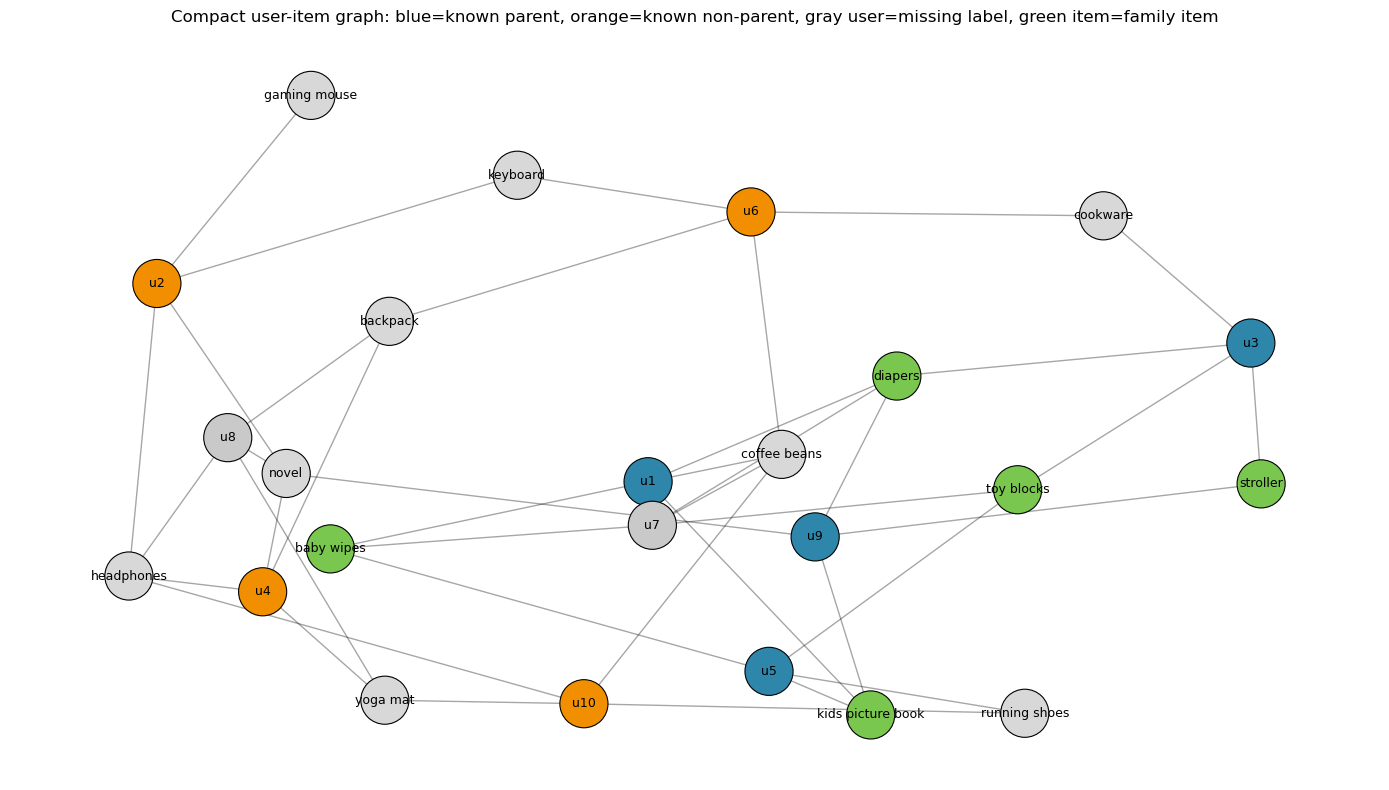

In [5]:
B = nx.Graph()

for _, row in users_observed.iterrows():
    B.add_node(
        f"u{int(row['user_id'])}",
        node_type="User",
        is_parent_observed=row["is_parent_observed"],
    )

for _, row in items.iterrows():
    B.add_node(
        row["item_name"],
        node_type="Item",
        family_signal=int(row["family_signal"]),
    )

item_names = items.set_index("item_id")["item_name"].to_dict()
for _, row in purchases.iterrows():
    B.add_edge(f"u{int(row['user_id'])}", item_names[row["item_id"]])

node_colors = []
for node, attrs in B.nodes(data=True):
    if attrs["node_type"] == "User":
        if pd.isna(attrs["is_parent_observed"]):
            node_colors.append("#C9C9C9")  # unknown label
        elif attrs["is_parent_observed"] == 1:
            node_colors.append("#2E86AB")  # known parent
        else:
            node_colors.append("#F18F01")  # known non-parent
    else:
        node_colors.append("#7AC74F" if attrs["family_signal"] == 1 else "#D8D8D8")

pos = nx.spring_layout(B, seed=7, k=0.85)
plt.figure(figsize=(14, 8))
nx.draw_networkx_edges(B, pos, alpha=0.35)
nx.draw_networkx_nodes(B, pos, node_color=node_colors, node_size=1200, edgecolors="black", linewidths=0.8)
nx.draw_networkx_labels(B, pos, font_size=9)
plt.title("Compact user-item graph: blue=known parent, orange=known non-parent, gray user=missing label, green item=family item")
plt.axis("off")
plt.tight_layout()
plt.show()

## 6. Compute Graph-Based Node Features

For each user node, we walk over paths of type:

`User -> Purchase -> Item`

Then we aggregate properties of the neighboring item nodes.

The important feature is:

\[
\text{family\_item\_share}(u) = \frac{\#\text{family items purchased by }u}{\#\text{items purchased by }u}
\]

This is a node feature for the user, computed from its graph neighborhood.

In [6]:
item_features = items.set_index("item_id").to_dict("index")


def purchased_item_ids_for_user(graph, user_id):
    # Return item ids reached by paths User -> Purchase -> Item.
    user_node = ("User", int(user_id))
    item_ids = []

    for purchase_node in graph.neighbors(user_node):
        if graph.nodes[purchase_node]["label"] != "Purchase":
            continue

        for maybe_item_node in graph.neighbors(purchase_node):
            if graph.nodes[maybe_item_node]["label"] == "Item":
                item_ids.append(int(maybe_item_node[1]))

    return item_ids


def compute_user_graph_features(graph, users_df):
    rows = []
    for user_id in users_df["user_id"]:
        item_ids = purchased_item_ids_for_user(graph, user_id)
        bought_items = [item_features[item_id] for item_id in item_ids]

        purchase_count = len(item_ids)
        family_count = sum(item["family_signal"] for item in bought_items)
        family_share = family_count / purchase_count if purchase_count else 0
        avg_price = np.mean([item["price"] for item in bought_items]) if purchase_count else 0
        unique_categories = len({item["category"] for item in bought_items})

        rows.append({
            "user_id": user_id,
            "purchase_count": purchase_count,
            "family_item_count": family_count,
            "family_item_share": family_share,
            "avg_purchased_item_price": round(avg_price, 2),
            "unique_purchased_categories": unique_categories,
        })

    return pd.DataFrame(rows)


user_graph_features = compute_user_graph_features(G, users_observed)
user_graph_features

,user_id,purchase_count,family_item_count,family_item_share,avg_purchased_item_price,unique_purchased_categories
0,1,4,3,0.75,14.75,3
1,2,4,0,0.00,55.25,2
2,3,4,3,0.75,70.75,3
3,4,4,0,0.00,50.25,4
4,5,4,3,0.75,34.00,4
5,6,4,0,0.00,50.00,4
6,7,4,3,0.75,18.75,3
7,8,4,0,0.00,50.25,4
8,9,4,3,0.75,57.00,3
9,10,4,0,0.00,55.00,3


In [7]:
def compute_family_item_share(graph, user_node):
    item_ids = []

    for purchase_node in graph.neighbors(user_node):
        if graph.nodes[purchase_node]["label"] != "Purchase": continue

        for maybe_item_node in graph.neighbors(purchase_node):
            if graph.nodes[maybe_item_node]["label"] == "Item":
                item_ids.append(int(maybe_item_node[1]))

    if not item_ids: return 0

    family_count = sum(item_features[item_id]["family_signal"] for item_id in item_ids)
    return family_count / len(item_ids)

## 7. Add the Computed Features Back to the User Table

This is the bridge between graph representation and ordinary tabular learning:

1. Start with relational tables.
2. Convert to a graph.
3. Compute graph features.
4. Join the features back into a standard table.
5. Train or apply a simple predictive rule.

In [8]:
learning_table = users_observed.merge(user_graph_features, on="user_id")

columns_to_show = ["user_id", "age", "is_parent_observed", "family_item_share"]

display_table = learning_table[columns_to_show].copy()
display_table["is_parent_observed"] = display_table["is_parent_observed"].astype("Int64")
display_table["..."] = "..."

styled_table = (
    display_table.style
    .format({"age": "{:.0f}", "family_item_share": "{:.2f}"}, na_rep="")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center")]},
    ])
)

display(styled_table)

,user_id,age,is_parent_observed,family_item_share,...
0,1,32,1,0.75,...
1,2,28,0,0.00,...
2,3,41,1,0.75,...
3,4,23,0,0.00,...
4,5,36,1,0.75,...
5,6,35,0,0.00,...
6,7,27,,0.75,...
7,8,29,,0.00,...
8,9,44,1,0.75,...
9,10,39,0,0.00,...


## 8. Learn a One-Feature Rule

To keep the example transparent, we learn the best threshold rule over one numeric feature.

Examples:

- age rule: `predict parent if age >= threshold`
- graph-feature rule: `predict parent if family_item_share >= threshold`

This is intentionally simple: the point is the feature, not the classifier.

In [9]:
def best_threshold_rule(train_df, feature, label="is_parent_observed"):
    values = sorted(train_df[feature].unique())
    candidate_thresholds = [values[0] - 1e-9]
    candidate_thresholds += [(a + b) / 2 for a, b in zip(values[:-1], values[1:])]
    candidate_thresholds += [values[-1] + 1e-9]

    best = None
    y_true = train_df[label].astype(int).to_numpy()

    for threshold in candidate_thresholds:
        x = train_df[feature].to_numpy()
        for direction in [">=", "<="]:
            if direction == ">=":
                y_pred = (x >= threshold).astype(int)
            else:
                y_pred = (x <= threshold).astype(int)

            accuracy = (y_pred == y_true).mean()
            candidate = {
                "feature": feature,
                "direction": direction,
                "threshold": threshold,
                "train_accuracy": accuracy,
            }

            if best is None or candidate["train_accuracy"] > best["train_accuracy"]:
                best = candidate

    return best


def apply_rule(df, rule):
    if rule["direction"] == ">=":
        return (df[rule["feature"]] >= rule["threshold"]).astype(int)
    return (df[rule["feature"]] <= rule["threshold"]).astype(int)


train = learning_table[learning_table["is_parent_observed"].notna()].copy()
unknown = learning_table[learning_table["is_parent_observed"].isna()].copy()

age_rule = best_threshold_rule(train, "age")
graph_rule = best_threshold_rule(train, "family_item_share")

age_rule, graph_rule

({'feature': 'age',
  'direction': '>=',
  'threshold': np.float64(30.0),
  'train_accuracy': np.float64(0.75)},
 {'feature': 'family_item_share',
  'direction': '>=',
  'threshold': np.float64(0.375),
  'train_accuracy': np.float64(1.0)})

## 9. Compare Raw Feature vs. Graph Feature

Both rules are learned only from users whose labels are observed.

Then we apply them to users 7 and 8, whose labels were hidden.

In [10]:
comparison = learning_table[[
    "user_id", "age", "family_item_share", "is_parent", "is_parent_observed"
]].copy()

comparison["age_rule_prediction"] = apply_rule(comparison, age_rule)
comparison["graph_rule_prediction"] = apply_rule(comparison, graph_rule)
comparison["label_was_hidden"] = comparison["is_parent_observed"].isna()

comparison

,user_id,age,family_item_share,is_parent,is_parent_observed,age_rule_prediction,graph_rule_prediction,label_was_hidden
0,1,32,0.75,1,1.0,1,1,False
1,2,28,0.00,0,0.0,0,0,False
2,3,41,0.75,1,1.0,1,1,False
3,4,23,0.00,0,0.0,0,0,False
4,5,36,0.75,1,1.0,1,1,False
5,6,35,0.00,0,0.0,1,0,False
6,7,27,0.75,1,NaN,0,1,True
7,8,29,0.00,0,NaN,0,0,True
8,9,44,0.75,1,1.0,1,1,False
9,10,39,0.00,0,0.0,1,0,False


In [11]:
def accuracy_on(df, prediction_col):
    return (df[prediction_col].astype(int) == df["is_parent"].astype(int)).mean()

summary = pd.DataFrame([
    {
        "model": "raw feature only: age",
        "learned_rule": f"is_parent = 1 if age {age_rule['direction']} {age_rule['threshold']:.2f}",
        "train_accuracy": age_rule["train_accuracy"],
        "hidden_label_accuracy": accuracy_on(comparison[comparison["label_was_hidden"]], "age_rule_prediction"),
    },
    {
        "model": "computed graph node feature: family_item_share",
        "learned_rule": (
            "is_parent = 1 if family_item_share "
            f"{graph_rule['direction']} {graph_rule['threshold']:.2f}"
        ),
        "train_accuracy": graph_rule["train_accuracy"],
        "hidden_label_accuracy": accuracy_on(comparison[comparison["label_was_hidden"]], "graph_rule_prediction"),
    },
])

summary

,model,learned_rule,train_accuracy,hidden_label_accuracy
0,raw feature only: age,is_parent = 1 if age >= 30.00,0.75,0.5
1,computed graph node feature: family_item_share,is_parent = 1 if family_item_share >= 0.38,1.00,1.0


## 10. Inspect the Missing-Label Users

The graph feature explains the predictions directly.

In [12]:
unknown_details = unknown[[
    "user_id", "age", "country", "purchase_count", "family_item_count", "family_item_share"
]].copy()
unknown_details["predicted_is_parent"] = apply_rule(unknown_details, graph_rule)
unknown_details.merge(users[["user_id", "is_parent"]], on="user_id")

,user_id,age,country,purchase_count,family_item_count,family_item_share,predicted_is_parent,is_parent
0,7,27,Israel,4,3,0.75,1,1
1,8,29,USA,4,0,0.00,0,0


## 11. Weisfeiler-Lehman (WL) Neighborhood Signatures

The **1-dimensional Weisfeiler-Lehman (1-WL) test** is an iterative color-refinement procedure.

At a high level:

1. Initialize each node with a discrete label/color.
2. At each iteration, replace each node color by a hash of its current color and the multiset of neighbor colors.
3. Nodes with the same WL color after several iterations have similar rooted neighborhood structure.

NetworkX exposes this idea through WL hashes. Here we use labels that do **not** include the target `is_parent` label:

- `User` nodes get label `User`.
- `Purchase` nodes get label `Purchase`.
- `Item` nodes get label `Item:family=0` or `Item:family=1`.

So the WL signatures can use item type information and graph structure, but they do not directly see the user label we want to predict.

In [13]:
from networkx.algorithms.graph_hashing import (
    weisfeiler_lehman_graph_hash,
    weisfeiler_lehman_subgraph_hashes,
)

# WL needs discrete node labels. Do not include is_parent here: that would leak the answer.
for node, attrs in G.nodes(data=True):
    if attrs["label"] == "Item":
        attrs["wl_label"] = f"Item:family={int(attrs['family_signal'])}"
    else:
        attrs["wl_label"] = attrs["label"]

# One hash for the whole heterogeneous graph.
whole_graph_wl_hash = weisfeiler_lehman_graph_hash(
    G,
    node_attr="wl_label",
    edge_attr="relation",
    iterations=2,
)

whole_graph_wl_hash

'f3af232c0e1f500f8f62f615debbb69a'

### Per-Node WL Signatures

`weisfeiler_lehman_subgraph_hashes` computes a sequence of WL hashes for each node. The last hash below is a compact signature of the node's local neighborhood after two WL refinement iterations.

In [14]:
wl_node_hashes = weisfeiler_lehman_subgraph_hashes(
    G,
    node_attr="wl_label",
    edge_attr="relation",
    iterations=2,
    include_initial_labels=True,
)

user_wl_rows = []
for user_id in users_observed["user_id"]:
    user_node = ("User", int(user_id))
    hashes = wl_node_hashes[user_node]
    user_wl_rows.append({
        "user_id": user_id,
        "initial_label_hash": hashes[0][:8],
        "after_1_iteration": hashes[1][:8],
        "after_2_iterations": hashes[2][:8],
        "is_parent_observed": G.nodes[user_node]["is_parent_observed"],
    })

user_wl_signatures = pd.DataFrame(user_wl_rows)
user_wl_signatures

,user_id,initial_label_hash,after_1_iteration,after_2_iterations,is_parent_observed
0,1,2e5ddaff,11cf466d,a7561098,1.0
1,2,2e5ddaff,11cf466d,3589886b,0.0
2,3,2e5ddaff,11cf466d,a7561098,1.0
3,4,2e5ddaff,11cf466d,3589886b,0.0
4,5,2e5ddaff,11cf466d,a7561098,1.0
5,6,2e5ddaff,11cf466d,3589886b,0.0
6,7,2e5ddaff,11cf466d,a7561098,NaN
7,8,2e5ddaff,11cf466d,3589886b,NaN
8,9,2e5ddaff,11cf466d,a7561098,1.0
9,10,2e5ddaff,11cf466d,3589886b,0.0


### Downstream Use: Classify Users by WL Ego-Graph Hash

A simple downstream use of WL is to turn each user's local neighborhood into a categorical feature.

For every user, we take the radius-2 ego graph around that user. In this schema, radius 2 captures exactly the pattern:

`User -> Purchase -> Item`

Then we compute a WL graph hash of that ego graph. Users with the same WL ego hash have the same refined neighborhood pattern under the labels we provided.

We classify hidden-label users by majority vote among labeled users with the same WL ego hash.

In [15]:
def user_ego_wl_hash(graph, user_id, radius=2, iterations=2):
    user_node = ("User", int(user_id))
    ego = nx.ego_graph(graph, user_node, radius=radius).copy()
    return weisfeiler_lehman_graph_hash(
        ego,
        node_attr="wl_label",
        edge_attr="relation",
        iterations=iterations,
    )

wl_feature_table = learning_table[[
    "user_id", "is_parent", "is_parent_observed", "family_item_share"
]].copy()

wl_feature_table["ego_wl_hash"] = wl_feature_table["user_id"].map(
    lambda user_id: user_ego_wl_hash(G, user_id)
)
wl_feature_table["ego_wl_hash_short"] = wl_feature_table["ego_wl_hash"].str[:10]

wl_feature_table[[
    "user_id", "family_item_share", "is_parent_observed", "ego_wl_hash_short"
]].sort_values(["ego_wl_hash_short", "user_id"])

,user_id,family_item_share,is_parent_observed,ego_wl_hash_short
1,2,0.00,0.0,3a5d7c2878
3,4,0.00,0.0,3a5d7c2878
5,6,0.00,0.0,3a5d7c2878
7,8,0.00,NaN,3a5d7c2878
9,10,0.00,0.0,3a5d7c2878
0,1,0.75,1.0,6237506085
2,3,0.75,1.0,6237506085
4,5,0.75,1.0,6237506085
6,7,0.75,NaN,6237506085
8,9,0.75,1.0,6237506085


In [16]:
known_wl_groups = (
    wl_feature_table[wl_feature_table["is_parent_observed"].notna()]
    .groupby("ego_wl_hash")
    .agg(
        n_labeled_users=("user_id", "size"),
        parent_rate=("is_parent_observed", "mean"),
    )
)

wl_predictions = wl_feature_table[wl_feature_table["is_parent_observed"].isna()].copy()
wl_predictions = wl_predictions.join(known_wl_groups, on="ego_wl_hash")
wl_predictions["predicted_is_parent"] = (wl_predictions["parent_rate"] >= 0.5).astype(int)
wl_predictions["correct"] = wl_predictions["predicted_is_parent"] == wl_predictions["is_parent"]

wl_predictions[[
    "user_id", "ego_wl_hash_short", "n_labeled_users", "parent_rate",
    "predicted_is_parent", "is_parent", "correct"
]]

,user_id,ego_wl_hash_short,n_labeled_users,parent_rate,predicted_is_parent,is_parent,correct
6,7,6237506085,4,1.0,1,1,True
7,8,3a5d7c2878,4,0.0,0,0,True


The WL hash is not a probability model by itself. It is a **structural feature**: a compact representation of a labeled local neighborhood. Once computed, it can be used like any other feature, for example for lookup, nearest-neighbor matching, grouping, or as an input column to a classifier.

## 12. Takeaway

The useful information was not in a single row of the `users` table.

It appeared after converting the relational data into a graph and aggregating information over the user's neighborhood:

`User -> Purchase -> Item`

The computed node feature `family_item_share` turns a structural pattern into a regular tabular feature that can be used for prediction.